In [2]:
# Import required library
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset from CSV file
data = pd.read_csv("Twitter_Data.csv")

# Display first 5 rows
print(data.head())

# Display dataset information
print(data.info())

# Check missing values
print(data.isnull().sum())

                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23941 entries, 0 to 23940
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   clean_text  23940 non-null  object 
 1   category    23940 non-null  float64
dtypes: float64(1), object(1)
memory usage: 374.2+ KB
None
clean_text    1
category      1
dtype: int64


In [3]:
# Display shape of dataset
print("Dataset Shape:", data.shape)

# Display column names
print("Columns:", data.columns)

# Summary statistics
print(data.describe())

# Count of each sentiment category
print(data['category'].value_counts())

# Percentage distribution
print(data['category'].value_counts(normalize=True) * 100)

# Check duplicate rows
print("Duplicate Rows:", data.duplicated().sum())

# Display random samples
print(data.sample(5))

Dataset Shape: (23941, 2)
Columns: Index(['clean_text', 'category'], dtype='object')
           category
count  23940.000000
mean       0.182414
std        0.791217
min       -1.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
category
 1.0    10075
 0.0     8157
-1.0     5708
Name: count, dtype: int64
category
 1.0    42.084378
 0.0    34.072682
-1.0    23.842941
Name: proportion, dtype: float64
Duplicate Rows: 0
                                              clean_text  category
19801  not unless modi afraid clowns rahul incs night...      -1.0
12788  sir from sep2018 have mail and tweet uidai por...      -1.0
15520  front modi karnataka bjp ’ are not opening the...       0.0
18231  nobody deserves philip kotler award more than ...       1.0
20019  what can your modi dad lol eat some beef birya...       1.0


In [4]:
# Import required libraries
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords
nltk.download('stopwords')

# Initialize stopwords
stop_words = set(stopwords.words('english'))

# Text cleaning function
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    text = " ".join([word for word in text.split() if word not in stop_words])

    return text

# Apply cleaning
data['clean_text'] = data['clean_text'].astype(str).apply(clean_text)

# Remove missing values
data = data.dropna()

# Reset index
data = data.reset_index(drop=True)

# Convert labels from (-1,0,1) to (0,1,2)
data['category'] = data['category'] + 1

# Convert labels to integer
data['category'] = data['category'].astype(int)

# Display cleaned data
print(data.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                          clean_text  category
0  modi promised minimum government maximum gover...         0
1             talk nonsense continue drama vote modi         1
2  say vote modi welcome bjp told rahul main camp...         2
3  asking supporters prefix chowkidar names modi ...         2
4  answer among powerful world leader today trump...         2


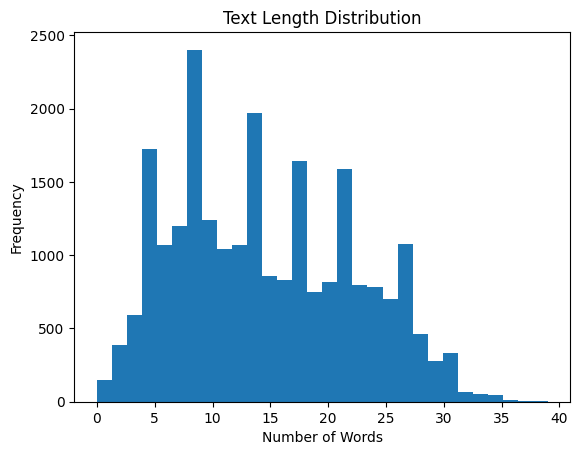

In [5]:
# Calculate text length
data['text_length'] = data['clean_text'].apply(lambda x: len(x.split()))

plt.figure()
plt.hist(data['text_length'], bins=30)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

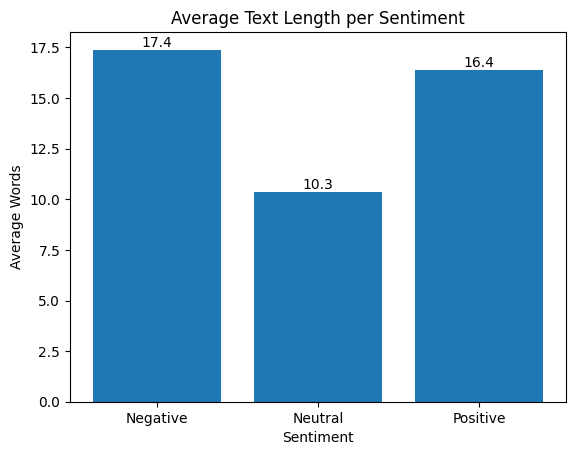

In [6]:
avg_length = data.groupby('category')['text_length'].mean()

labels = ['Negative', 'Neutral', 'Positive']

plt.figure()
bars = plt.bar(labels, avg_length)

# Add values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval,1),
             ha='center', va='bottom')

plt.title("Average Text Length per Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Words")

plt.show()

In [7]:
# Reduce dataset size for faster training
data = data.sample(20000, random_state=42).reset_index(drop=True)

In [8]:
from transformers import DistilBertTokenizer

# Load DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Encode all text data
encoded_data = tokenizer(
    data['clean_text'].tolist(),
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors='pt'
)

# Extract input IDs and attention masks
input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']

# Display shapes
print("Input shape:", input_ids.shape)
print("Attention mask shape:", attention_masks.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Input shape: torch.Size([20000, 32])
Attention mask shape: torch.Size([20000, 32])


In [9]:
from sklearn.model_selection import train_test_split

# Train (80%) and Temp (20%)
train_inputs, temp_inputs, train_labels, temp_labels = train_test_split(
    input_ids,
    data['category'].values,
    test_size=0.2,
    random_state=42,
    stratify=data['category'].values
)

train_masks, temp_masks, _, _ = train_test_split(
    attention_masks,
    data['category'].values,
    test_size=0.2,
    random_state=42,
    stratify=data['category'].values
)

# Validation (10%) and Test (10%)
val_inputs, test_inputs, val_labels, test_labels = train_test_split(
    temp_inputs,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

val_masks, test_masks, _, _ = train_test_split(
    temp_masks,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

# Display shapes
print("Train Shape:", train_inputs.shape)
print("Validation Shape:", val_inputs.shape)
print("Test Shape:", test_inputs.shape)

Train Shape: torch.Size([16000, 32])
Validation Shape: torch.Size([2000, 32])
Test Shape: torch.Size([2000, 32])


In [10]:
from transformers import DistilBertForSequenceClassification

# Load pre-trained DistilBERT model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3   # negative, neutral, positive
)

print("DistilBERT model loaded successfully")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully


In [11]:
import torch

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model.to(device)

print("Device used:", device)

Device used: cuda


In [12]:
from transformers import DistilBertForSequenceClassification
import torch

# Load pre-trained DistilBERT model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

# Check device (CPU/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model.to(device)

print("Model initialized successfully")
print("Device used:", device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model initialized successfully
Device used: cuda


In [13]:
from torch.utils.data import TensorDataset, DataLoader
import torch

# Convert labels to tensor
train_labels = torch.tensor(train_labels, dtype=torch.long)
val_labels = torch.tensor(val_labels, dtype=torch.long)

# Create training and validation datasets
train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
val_dataset = TensorDataset(val_inputs, val_masks, val_labels)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# Display number of batches
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 250
Validation batches: 32


In [34]:
from torch.optim import AdamW
from tqdm import tqdm

# Define optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Set number of epochs
epochs = 1   # reduced for faster training

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):

        # Move batch to device
        batch = tuple(t.to(device) for t in batch)
        input_ids, attention_mask, labels = batch

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

    # Average loss
    avg_loss = total_loss / len(train_loader)
    print("Training Loss:", avg_loss)


Epoch 1/1


100%|██████████| 250/250 [00:45<00:00,  5.48it/s]

Training Loss: 0.03881736353319138


In [35]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in val_loader:

        # Move batch to device
        batch = tuple(t.to(device) for t in batch)
        input_ids, attention_mask, labels = batch

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        # Get predicted class
        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Accuracy
accuracy = accuracy_score(true_labels, predictions)
print("Validation Accuracy:", accuracy)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(true_labels, predictions))

Validation Accuracy: 0.835

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.80      0.77       474
           1       0.87      0.86      0.86       684
           2       0.86      0.83      0.85       842

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.84      0.83      0.84      2000



In [36]:
# Convert test labels to tensor
test_labels = torch.tensor(test_labels, dtype=torch.long)

# Create test dataset
test_dataset = TensorDataset(test_inputs, test_masks, test_labels)

# Create test DataLoader
test_loader = DataLoader(test_dataset, batch_size=64)

print("Test batches:", len(test_loader))

Test batches: 32


/tmp/ipykernel_8568/746218862.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_labels = torch.tensor(test_labels, dtype=torch.long)


In [37]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()

test_predictions = []
test_true_labels = []

with torch.no_grad():
   for batch in test_loader:

        # Move batch to device
        batch = tuple(t.to(device) for t in batch)
        input_ids, attention_mask, labels = batch

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        # Get predicted class
        preds = torch.argmax(logits, dim=1)

        test_predictions.extend(preds.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

# Accuracy
test_accuracy = accuracy_score(test_true_labels, test_predictions)
print("Test Accuracy:", test_accuracy)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(test_true_labels, test_predictions))

Test Accuracy: 0.847

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       474
           1       0.88      0.86      0.87       684
           2       0.88      0.85      0.86       842

    accuracy                           0.85      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.85      0.85      0.85      2000



In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Accuracy
accuracy = accuracy_score(test_true_labels, test_predictions)

# Precision
precision = precision_score(test_true_labels, test_predictions, average='weighted')

# Recall
recall = recall_score(test_true_labels, test_predictions, average='weighted')

# F1 Score
f1 = f1_score(test_true_labels, test_predictions, average='weighted')

# Display results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.847
Precision: 0.8501268826541526
Recall: 0.847
F1 Score: 0.8479747089387333


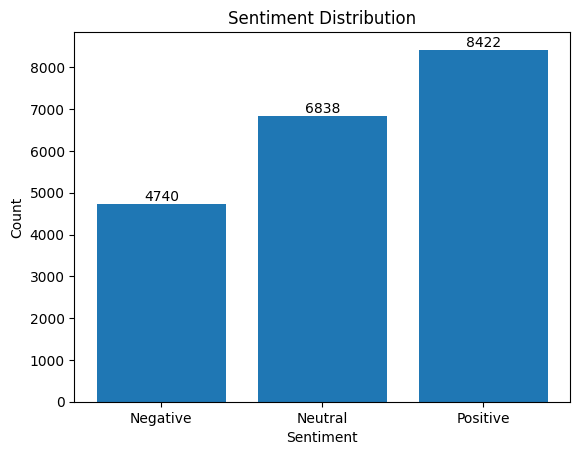

In [39]:
import matplotlib.pyplot as plt

labels = ['Negative', 'Neutral', 'Positive']
counts = data['category'].value_counts().sort_index()

plt.figure()
bars = plt.bar(labels, counts)

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

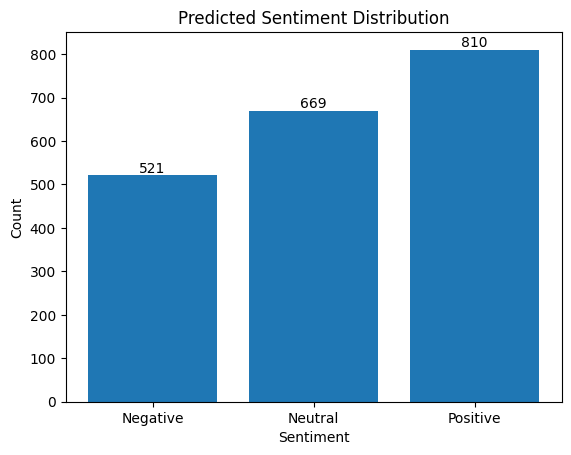

In [40]:
import numpy as np

pred_counts = np.bincount(test_predictions)

plt.figure()
bars = plt.bar(labels, pred_counts)

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.title("Predicted Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

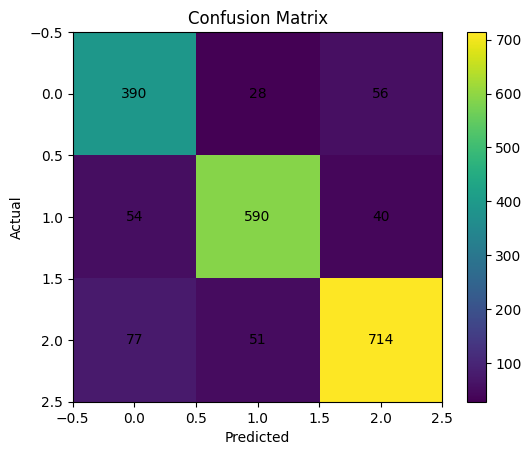

In [41]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(test_true_labels, test_predictions)

plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

# Add values inside matrix
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Convert text into numerical features
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data['clean_text'])
y = data['category']

# Split dataset (same ratio)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Prediction
y_pred = nb_model.predict(X_test)

# Evaluation
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Naive Bayes Accuracy: 0.67725

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.39      0.54       948
           1       0.77      0.60      0.68      1368
           2       0.61      0.90      0.73      1684

    accuracy                           0.68      4000
   macro avg       0.74      0.63      0.65      4000
weighted avg       0.72      0.68      0.66      4000



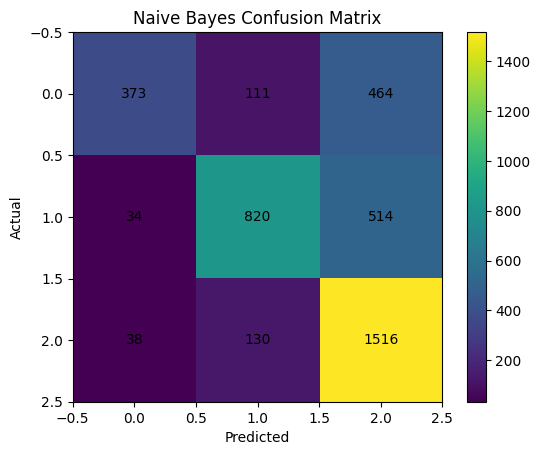

In [43]:
# Confusion Matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm_nb)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

for i in range(len(cm_nb)):
    for j in range(len(cm_nb)):
        plt.text(j, i, cm_nb[i][j], ha='center', va='center')

plt.show()